# 使用 PROC BOX 可视化急诊科住院时长

## 执行摘要

一项医院运营分析，使用 PROC BOXPLOT（别名 PROC BOX）比较三个临床科室的急诊科住院时长。并排的示意箱线图一目了然地展示每个科室的中位数、四分位数、均值以及长时住院的离群值。

在 100 次模拟就诊中，住院时长中位数从 **内科的 40.0 小时** 稳步上升到 **外科的 50.4 小时** 再到 **创伤科的 60.5 小时**，均值也遵循相同顺序（41.6、54.6、62.8 小时）。外科在上须之上有三个高离群值（最高达 84.3 小时）——即占用床时最多的滞留病例。本笔记本以三种方式展示该比较：示意图、均值趋势叠加图以及横向布局。

## 数据来源

所有数据均由第一个 DATA 步内联生成（`call streaminit(20260531)`）；未使用任何外部或网络输入。

**`ed_los`** — 每行对应一次急诊科就诊（100 行）

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `PatientID` | Num | 顺序就诊标识（1-100） |
| `Department` | Char(12) | 收治科室：Medicine、Surgery、Trauma |
| `Severity` | Char(8) | 分诊急重度：Routine（约 55%）、Urgent（约 30%）、Critical（约 15%） |
| `LOS_Hours` | Num | 住院时长（小时）；由科室与急重度驱动的均值加正态噪声，并偶发长时住院冲击（标签为 "Length of Stay (hours)"） |

实际构成为内科 34 / 外科 36 / 创伤科 30 次就诊，按分诊急重度为 Routine 51 / Urgent 35 / Critical 14。

# 使用 PROC BOX 可视化急诊科住院时长

住院时长（LOS）是医院急诊科最受关注的运营指标之一：它影响床位可用性、人员配置、患者吞吐量和质量评分。仅看均值会掩盖真相——运营团队真正关心的是住院时长的*离散程度*、占用资源的*离群值*，以及各临床科室之间分布的差异。

PROC BOX（PROC BOXPLOT 的别名）正是为此类比较量身打造的。它绘制并排的箱须图，标出每组的中位数、四分位数、均值和极端观测，使分析师能够一目了然地读出每个科室 LOS 分布的形状。

在本笔记本中，我们将：

1. 生成一个适配 100 观测环境的合成急诊就诊数据集。
2. 生成按科室划分的 LOS 示意箱线图，并附带统计量表。
3. 用 `BOXCONNECT=MEAN` 叠加均值趋势线，使科室梯度更清晰。
4. 用 `HORIZONTAL` 将同一比较横向重绘。

## 步骤 1 — 生成合成急诊就诊数据

我们模拟 100 次急诊科就诊。每位患者被分配到三个临床科室之一（Medicine、Surgery、Trauma）以及一个分诊急重度（Routine、Urgent、Critical）。住院时长由科室特定的基线构建，对急重度更高的患者向上平移，并叠加正态分布噪声。一小部分就诊会额外获得长时住院冲击，以模拟真实急诊数据始终呈现的厚重右尾（滞留、等待住院床位的收治）。`call streaminit` 中的固定种子使数据集完全可复现。

In [1]:
选项 linesize=96;

数据 ed_los;
   调用 streaminit(20260531);
   长度 Department $ 18 Severity $ 12;
   循环 PatientID = 1 到 100;
      d = rand('integer', 1, 3);
      如果 d = 1 那么 Department = '内科';
      否则 如果 d = 2 那么 Department = '外科';
      否则 Department = '创伤科';

      u = rand('uniform');
      如果 u < 0.55 那么 s = 1;
      否则 如果 u < 0.85 那么 s = 2;
      否则 s = 3;
      如果 s = 1 那么 Severity = '常规';
      否则 如果 s = 2 那么 Severity = '紧急';
      否则 Severity = '危重';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      如果 rand('uniform') < 0.06 那么
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      如果 LOS_Hours < 2 那么 LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      输出;
   结束;
   删除 d u s BASE;
   标签 LOS_Hours = '停留时长(小时)' Department = '科室' Severity = '严重程度';
运行;



NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## 步骤 2 — 按分组变量排序

PROC BOX 要求分组（横轴）变量已排序，以便每组的观测连续排列。我们在绘图前按 `Department` 排序。

In [2]:
过程 排序 数据=ed_los;
   按照 Department;
运行;



NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## 步骤 3 — 示意箱线图

核心分析。`PLOT analysis-var * group-var` 语法为每个科室请求一个箱体。`BOXSTYLE=SCHEMATIC` 生成经典的 Tukey 示意图：须延伸至四分位距 1.5 倍范围内最极端的观测，超出部分则作为离群值单独绘出——非常适合发现给容量带来压力的长时住院病例。

`NOHLABEL` 抑制冗余的横轴标签，因为科室名称本身已足够清晰。在图旁，PROC BOXPLOT 打印一张统计量表，给出每个科室的 N、最小值、四分位数、中位数、最大值、均值和标准差。

                                           急诊各科室停留时长                                            

                                  急诊各科室停留时长

                                     The BOXPLOT Procedure

Schematic Plots for 停留时长(小时)

科室                    N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
内科                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
创伤科                  30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
外科                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 急诊各科室停留时长.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


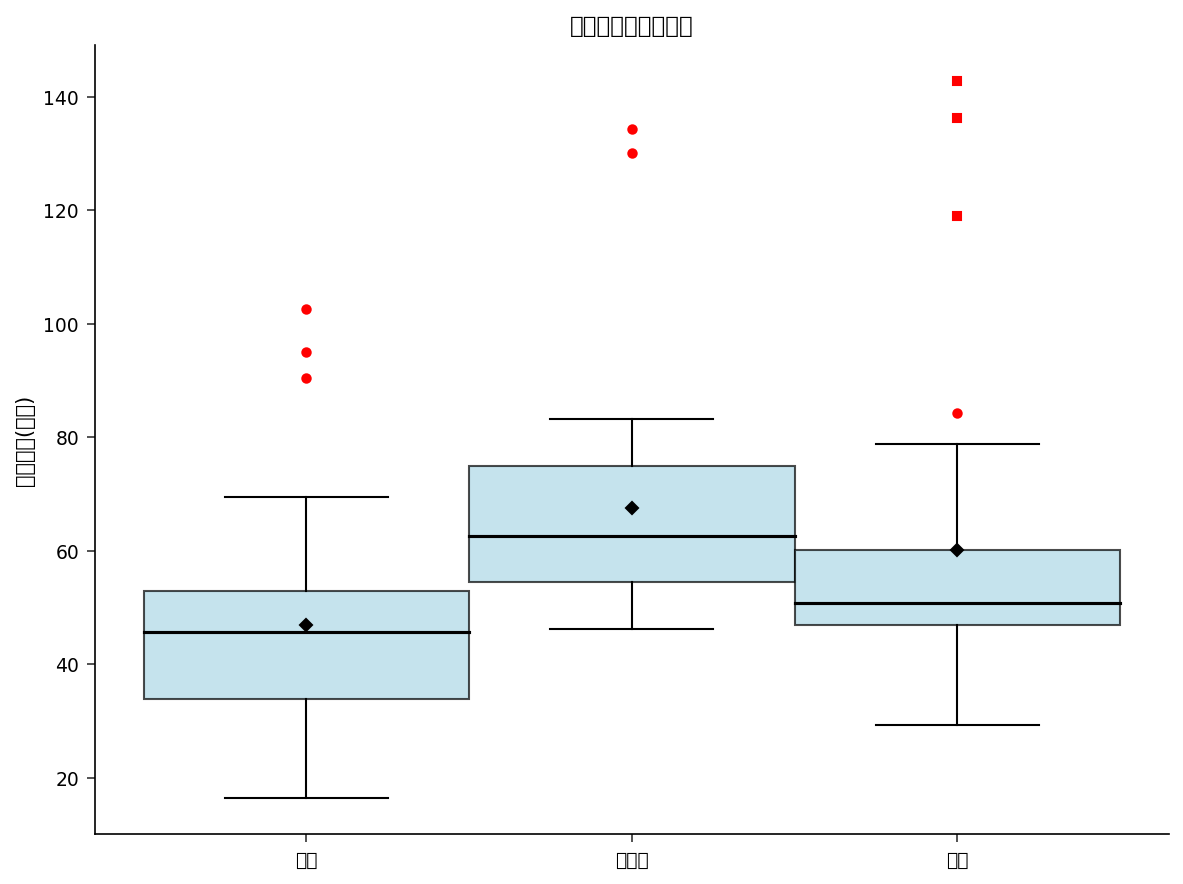

In [3]:
标题 '急诊各科室停留时长';
过程 boxplot 数据=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
运行;


## 步骤 4 — 叠加均值趋势线

为使科室之间的梯度更清晰，我们添加 `BOXCONNECT=MEAN`。PROC BOXPLOT 随后绘制一条穿过每个箱体均值（菱形标记）的连线，将三个独立分布转化为一条易读的趋势。由于科室按 Medicine → Surgery → Trauma 排序，上升的连线一笔勾勒出平均住院时长的递增——这是运营仪表板的有用线索。

                                        急诊各科室停留时长 — 均值趋势                                        

                          急诊各科室停留时长 — 均值趋势

                                     The BOXPLOT Procedure

Schematic Plots for 停留时长(小时)

科室                    N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
内科                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
创伤科                  30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
外科                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 急诊各科室停留时长 — 均值趋势.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


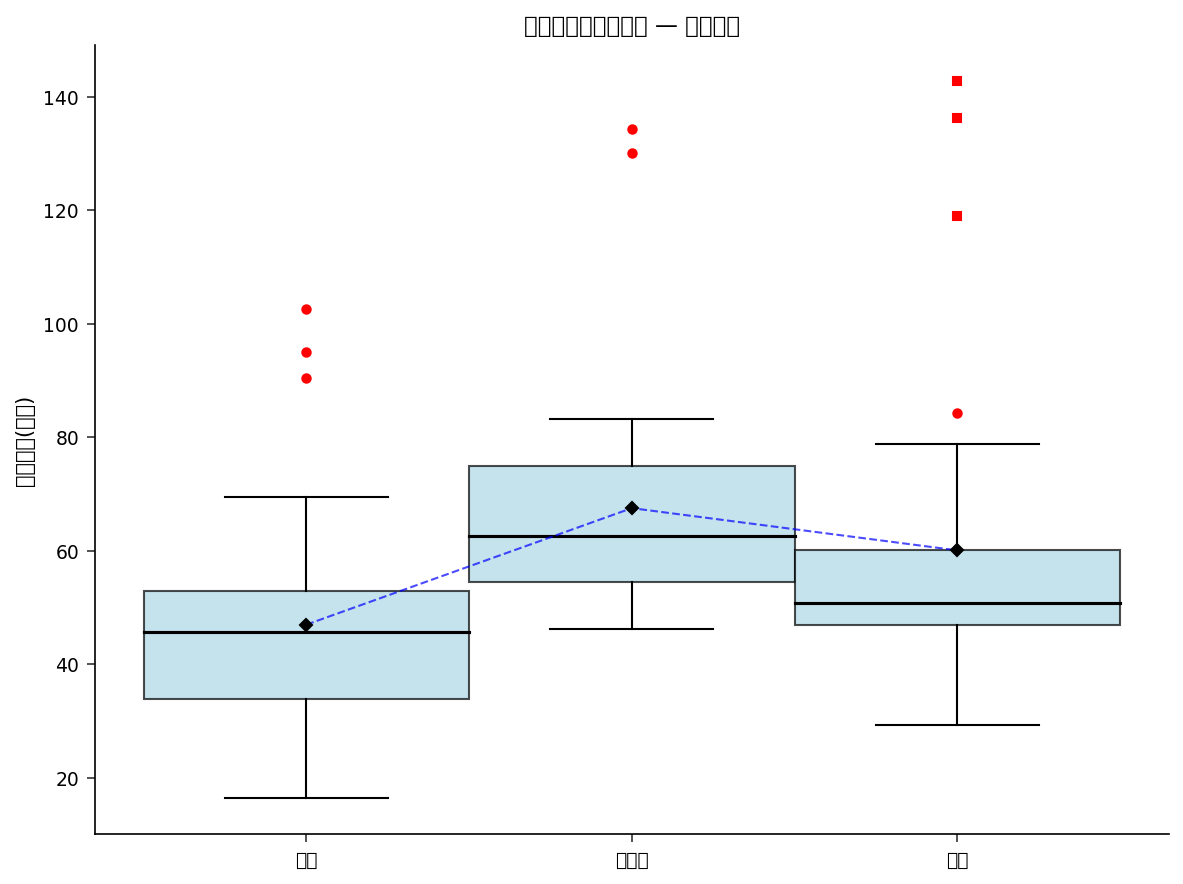

In [4]:
标题 '急诊各科室停留时长 — 均值趋势';
过程 boxplot 数据=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
运行;


## 步骤 5 — 横向布局

同样的比较横向阅读也很自然。添加 `HORIZONTAL` 会交换坐标轴，使箱体从左到右排列、响应变量位于 x 轴——当科室名称较长或较多时，这种布局扩展性更好，也是许多运营仪表板偏好的方式。统计量与纵向视图完全相同，仅方向发生变化。

                                         急诊各科室停留时长 — 横向                                         

                             急诊各科室停留时长 — 横向

                                     The BOXPLOT Procedure

Schematic Plots for 停留时长(小时)

科室                    N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
内科                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
创伤科                  30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
外科                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 急诊各科室停留时长 — 横向.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


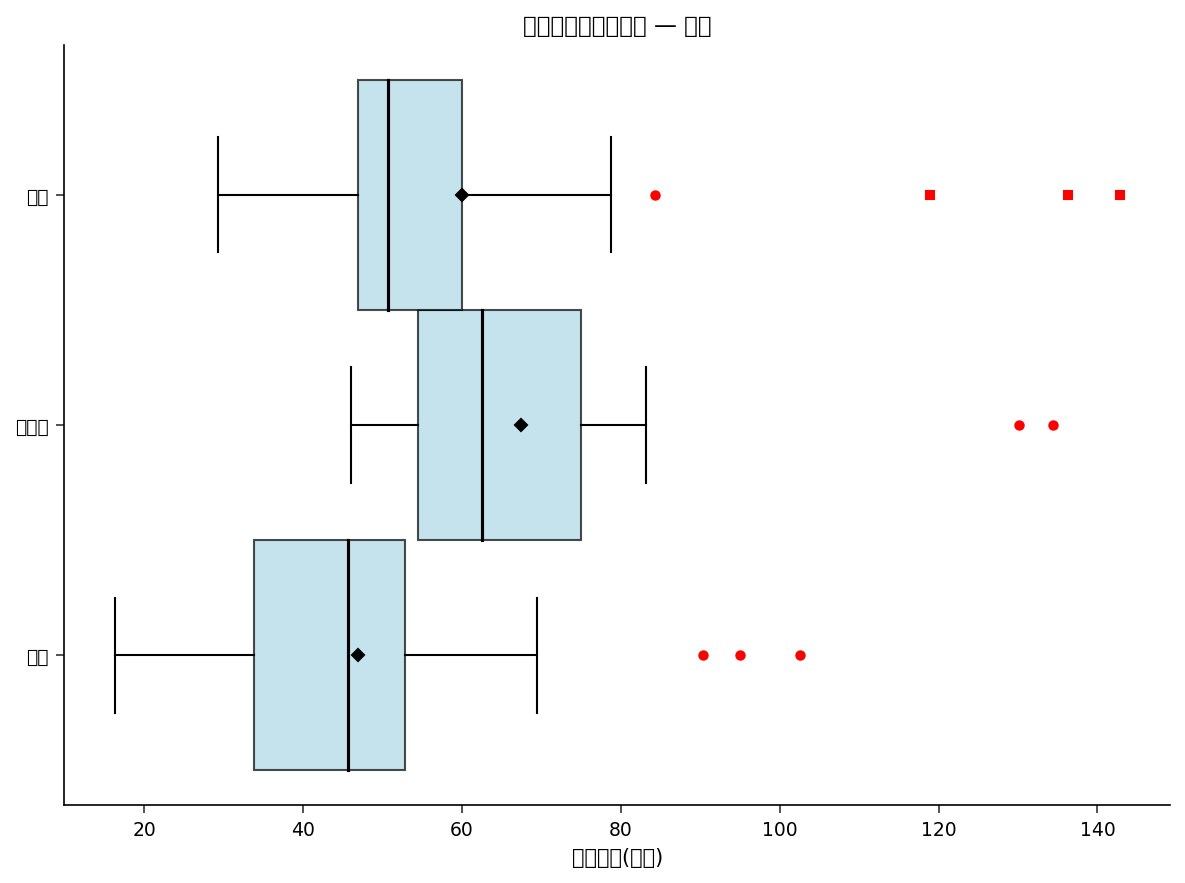

In [5]:
标题 '急诊各科室停留时长 — 横向';
过程 boxplot 数据=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
运行;


## 结果解读

箱线图与随附的统计量表将原始 LOS 数据转化为可用于运营决策的图景：

- **清晰的科室梯度。** 住院时长中位数在三个科室间单调上升：**内科 40.0 h → 外科 50.4 h → 创伤科 60.5 h**。均值讲述了同样的故事（41.6、54.6、62.8 h），步骤 4 中的 `BOXCONNECT=MEAN` 线将这种递增绘成一条上升趋势。创伤科患者平均住院时长比内科患者长约 50%。

- **变异性与中位数同样重要。** 四分位距（箱体高度）在内科最宽（Q1 32.8 h 到 Q3 51.2 h，跨度 18.3 小时），在创伤科最窄（Q1 54.5 h 到 Q3 68.5 h，跨度 14.0 小时）。因此内科不仅是住院时长最短的科室，也是最难预测的——这一特性使床位管理预测更为复杂。

- **离群值标识滞留病例。** 示意须止于 1.5 × IQR，因此外科上须之上的三个红点（峰值 84.3 h）作为真正的长时住院就诊而突出——正是占用不成比例床时的滞留病例。在本样本中，内科和创伤科没有超出各自须之外的点。

- **极差讲述容量规划的故事。** 观测到的住院时长在内科为 16.3–69.5 h，外科为 29.3–84.3 h，创伤科为 46.1–83.2 h。创伤科从不产生短时住院（其最小值 46.1 h 已超过内科的中位数），这正是运营团队对这个资源最密集科室的预期。

综合来看，这些视图为急诊科管理团队提供了一个有据可依、关注分布的基础，用于人员配置与容量规划——远比仅比较各科室平均 LOS 更有信息量。